# Momepy roads - Zaragoza

This notebook uses momepy to calculate geometrical and topological features of the Zaragoza street network:
- **Street profile**: `width`, `openness`, `width_deviation` (requires OSM buildings)
- **Betweenness centrality** (edge-based, global, propagated via mean_nodes)
- **Closeness centrality** -- global and local 400 m
- **Straightness centrality** (node-based, global)

Input: `ZGZ_noise_streets.gpkg` -- the Zaragoza OSM drive streets with the noise-map classes.

## Import libraries

In [1]:
import os
import momepy as mm
import geopandas as gpd
import osmnx as ox
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Import streets segments

In [2]:
_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
edges = gpd.read_file(os.path.join(_layers_dir, 'ZGZ_noise_streets.gpkg'))
print(edges.crs)
print(edges.shape)
print(edges.columns.tolist())
print('Number of street segments:', len(edges))

EPSG:25830
(14600, 11)
['segment_id', 'highway', 'name', 'length', 'db_day', 'db_evening', 'db_night', 'noise_day', 'noise_evening', 'noise_night', 'geometry']
Number of street segments: 14600


C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


In [3]:
place_name = 'Zaragoza, Spain'
tags = {'building': True}

print('Downloading buildings from OSM...')
try:
    buildings = ox.features_from_place(place_name, tags)
except AttributeError:
    buildings = ox.geometries_from_place(place_name, tags)

print(f'Downloaded {len(buildings)} buildings.')
buildings = buildings[buildings.geometry.type.isin(['Polygon', 'MultiPolygon'])]
buildings = buildings.to_crs(edges.crs)
print(f'Polygon buildings: {len(buildings)}')

Downloaded 22459 buildings.


Polygon buildings: 22336


## Create Momepy street profile

In [4]:
profile = mm.street_profile(edges, buildings)
profile.head()

,width,openness,width_deviation
0,14.944760,0.375000,0.875412
1,32.776400,0.625000,4.648335
2,37.421218,0.500000,2.556000
3,50.000000,1.000000,NaN
4,40.184419,0.666667,3.178716


In [5]:
edges[profile.columns] = profile
edges[profile.columns].head()

,width,openness,width_deviation
0,14.944760,0.375000,0.875412
1,32.776400,0.625000,4.648335
2,37.421218,0.500000,2.556000
3,50.000000,1.000000,NaN
4,40.184419,0.666667,3.178716


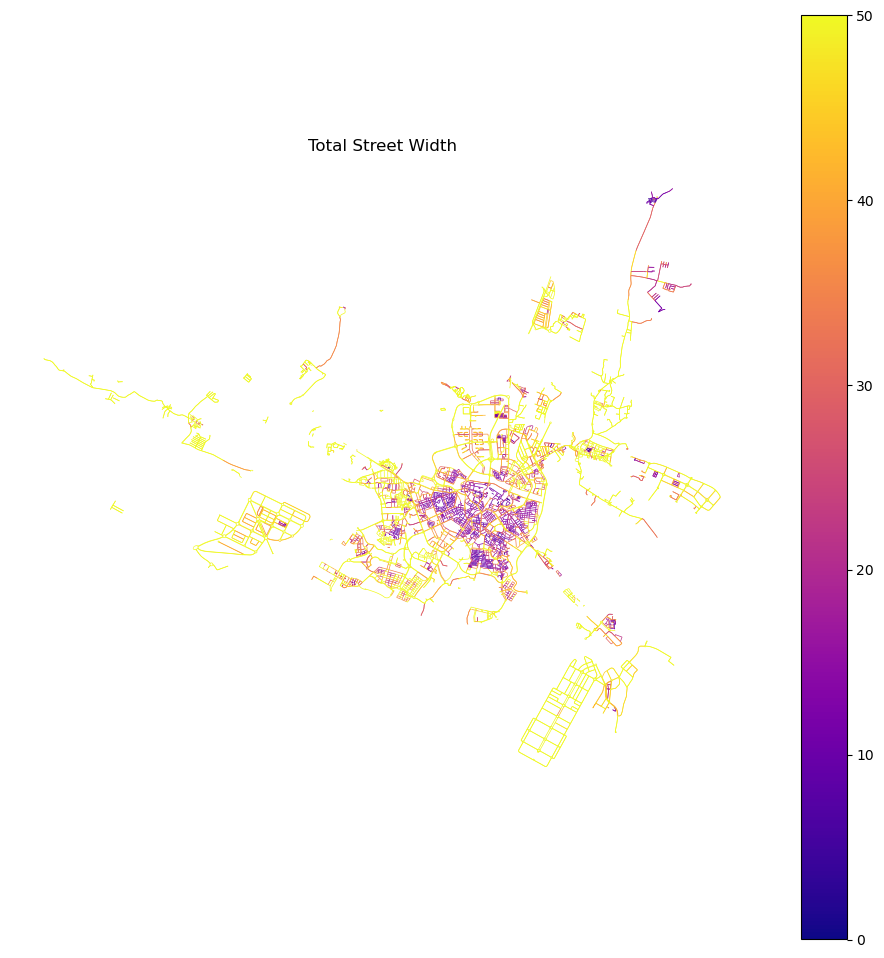

In [6]:
ax = edges.plot(cmap='plasma', column='width', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Total Street Width')
ax.set_axis_off()

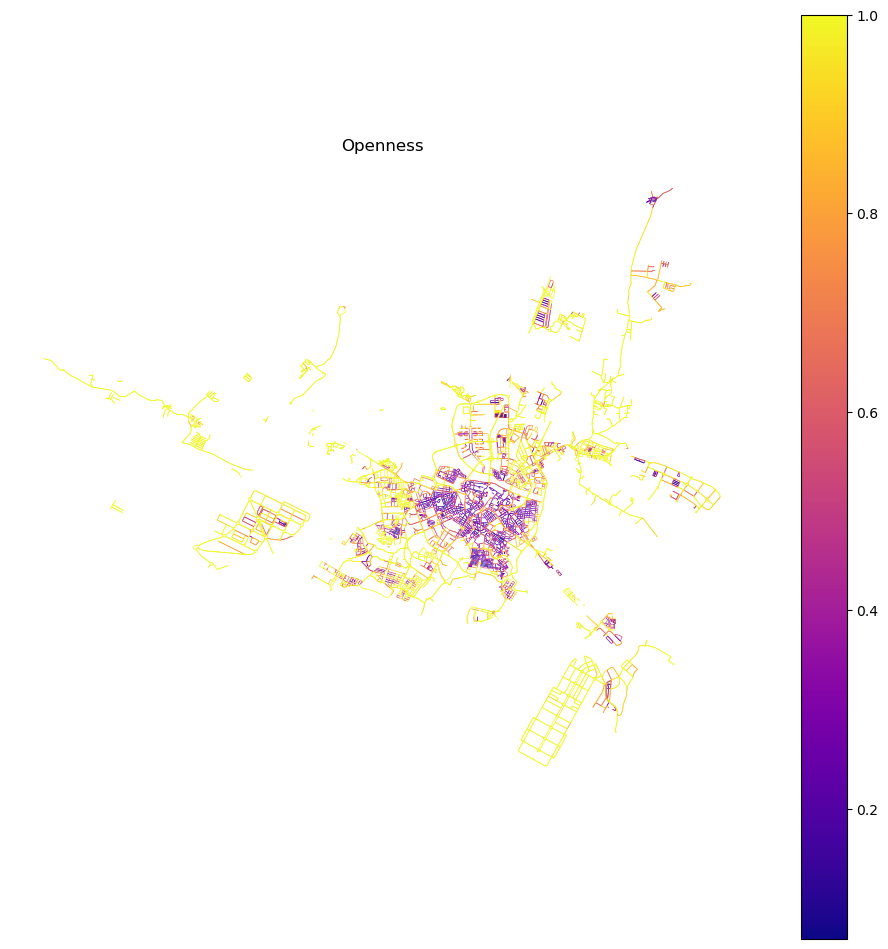

In [7]:
ax = edges.plot(cmap='plasma', column='openness', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Openness')
ax.set_axis_off()

# Centrality

Build the primal graph once; all centrality functions operate on it.

In momepy 0.11 all centralities are node-based. `mm.mean_nodes()` propagates each
node attribute to its incident edges (mean of the two endpoint values) before the
edge GeoDataFrame is extracted.

In [8]:
primal = mm.gdf_to_nx(edges, approach="primal")
print('Graph nodes:', primal.number_of_nodes(), '  edges:', primal.number_of_edges())

Graph nodes: 8319   edges: 14600


## Betweenness Centrality

In [9]:
betweenness = mm.betweenness_centrality(
    primal, name='betweenness_metric_e', mode='edges', weight='mm_len',
)

In [10]:
primal_gdf_betw = mm.nx_to_gdf(betweenness, points=False)
primal_gdf_betw.head()

,segment_id,highway,name,length,db_day,db_evening,db_night,noise_day,noise_evening,noise_night,geometry,width,openness,width_deviation,mm_len,betweenness_metric_e
0,30389382_249502424_0,residential,Calle Bruno Solano,61.613974,65.0,65.0,55.0,3,3,2,"LINESTRING (675261.037 4611935.746, 675263.416...",14.944760,0.375000,0.875412,61.701200,0.000679
1,30389382_30389461_0,primary,Paseo de Fernando el Católico,83.332676,75.0,70.0,60.0,4,4,3,"LINESTRING (675261.037 4611935.746, 675265.706...",32.776400,0.625000,4.648335,83.339083,0.014229
2,30389471_30389382_0,primary,Paseo de Fernando el Católico,148.754075,75.0,70.0,60.0,4,4,3,"LINESTRING (675177.171 4611812.87, 675183.439 ...",30.712891,0.578947,0.606859,148.768331,0.014787
3,249502424_249502441_0,residential,Calle Bruno Solano,62.446394,65.0,65.0,55.0,3,3,2,"LINESTRING (675313.172 4611902.746, 675365.929...",15.167460,0.250000,0.664342,62.534283,0.000249
4,249502424_266326619_0,residential,"['Calle de Félix Latassa', 'Calle de Don André...",128.472933,65.0,65.0,55.0,3,3,2,"LINESTRING (675313.172 4611902.746, 675352.306...",11.956801,0.416667,0.916044,128.478022,0.000523


Text(0.5, 1.0, 'Betweenness Centrality - Edge Mean (r=500 m)')

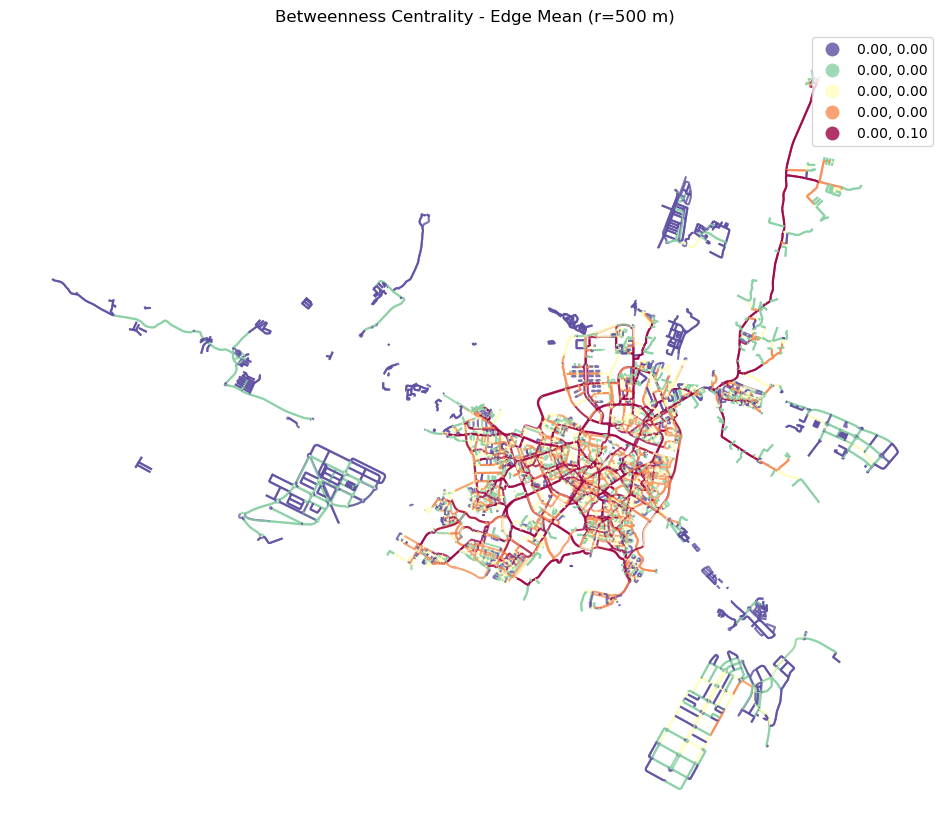

In [11]:
ax = primal_gdf_betw.plot(
    column='betweenness_metric_e',
    cmap='Spectral_r',
    scheme='quantiles',
    alpha=0.8,
    legend=True,
    figsize=(12, 12)
)
ax.set_axis_off()
ax.set_title('Betweenness Centrality - Edge Mean (r=500 m)')

## Global Closeness Centrality

Careful, takes a few minutes

In [12]:
closeness = mm.closeness_centrality(
    primal, name='closeness_global', weight='mm_len'
)

In [13]:
nodes = mm.nx_to_gdf(closeness, lines=False)
nodes.head()
nodes.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8319 entries, 0 to 8318
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   x                 8319 non-null   float64 
 1   y                 8319 non-null   float64 
 2   closeness_global  8319 non-null   float64 
 3   nodeID            8319 non-null   int64   
 4   geometry          8319 non-null   geometry
dtypes: float64(3), geometry(1), int64(1)
memory usage: 325.1 KB


Text(0.5, 1.0, 'Closenness Global (Node Based)')

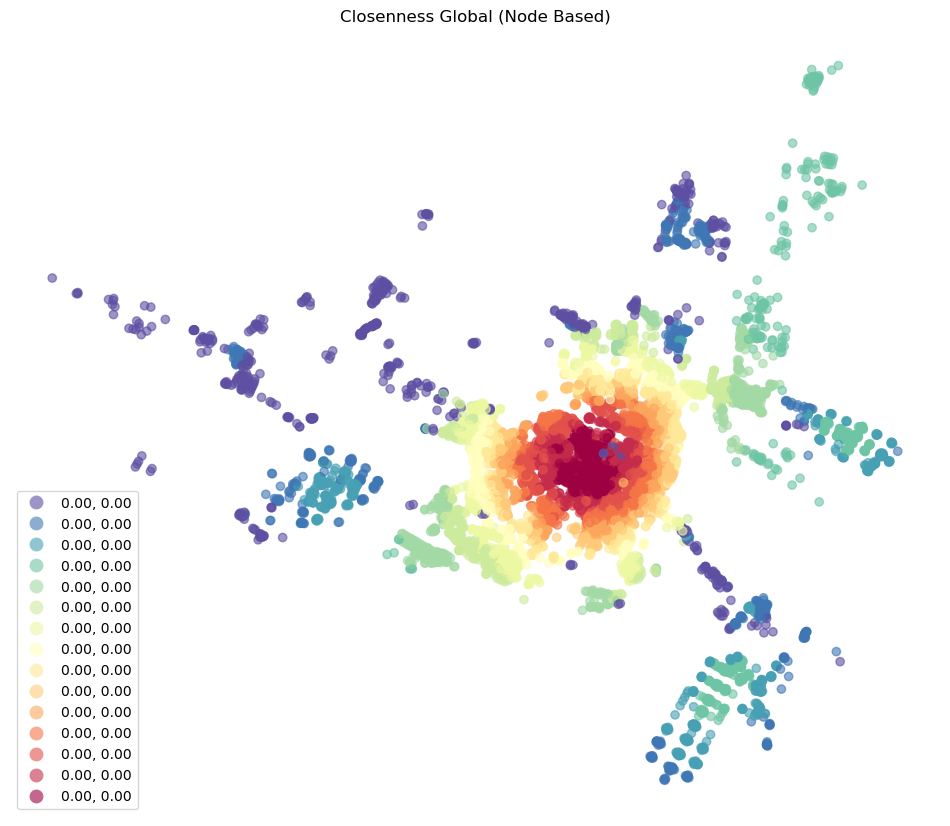

In [14]:
ax = nodes.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
ax.set_title("Closenness Global (Node Based)")

In [15]:
mm.mean_nodes(closeness, "closeness_global")

In [16]:
primal_gdf_clos = mm.nx_to_gdf(closeness, points=False)
primal_gdf_clos.head()

,segment_id,highway,name,length,db_day,db_evening,db_night,noise_day,noise_evening,noise_night,geometry,width,openness,width_deviation,mm_len,closeness_global
0,30389382_249502424_0,residential,Calle Bruno Solano,61.613974,65.0,65.0,55.0,3,3,2,"LINESTRING (675261.037 4611935.746, 675263.416...",14.944760,0.375000,0.875412,61.701200,0.000191
1,30389382_30389461_0,primary,Paseo de Fernando el Católico,83.332676,75.0,70.0,60.0,4,4,3,"LINESTRING (675261.037 4611935.746, 675265.706...",32.776400,0.625000,4.648335,83.339083,0.000192
2,30389471_30389382_0,primary,Paseo de Fernando el Católico,148.754075,75.0,70.0,60.0,4,4,3,"LINESTRING (675177.171 4611812.87, 675183.439 ...",30.712891,0.578947,0.606859,148.768331,0.000191
3,249502424_249502441_0,residential,Calle Bruno Solano,62.446394,65.0,65.0,55.0,3,3,2,"LINESTRING (675313.172 4611902.746, 675365.929...",15.167460,0.250000,0.664342,62.534283,0.000189
4,249502424_266326619_0,residential,"['Calle de Félix Latassa', 'Calle de Don André...",128.472933,65.0,65.0,55.0,3,3,2,"LINESTRING (675313.172 4611902.746, 675352.306...",11.956801,0.416667,0.916044,128.478022,0.000191


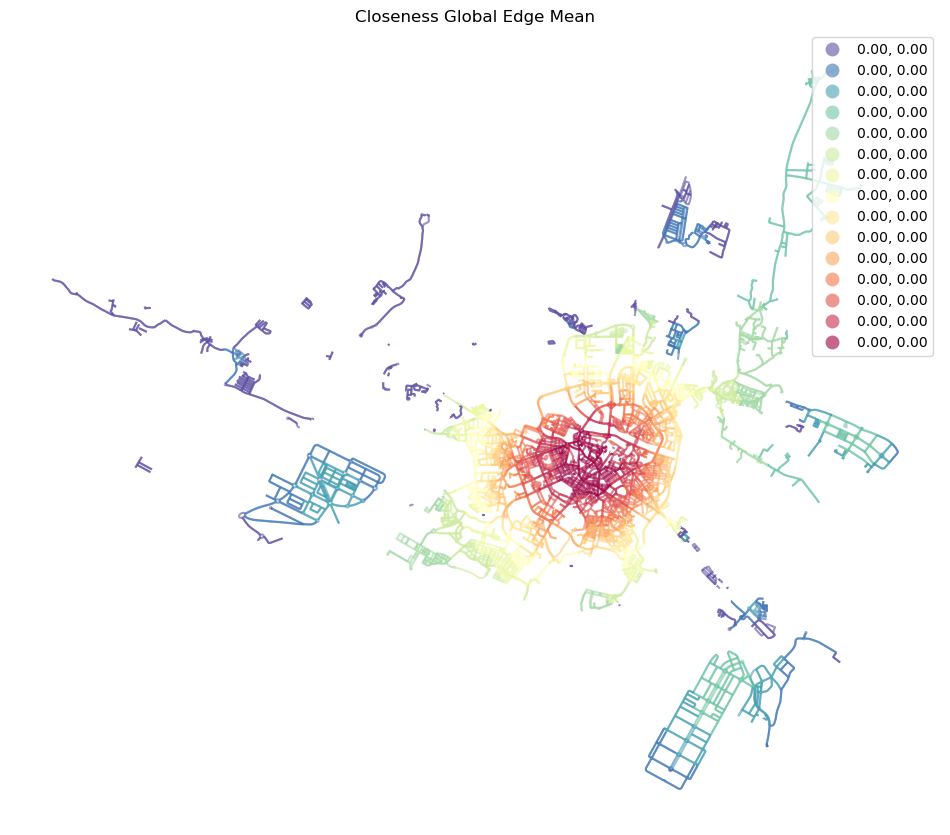

In [17]:

ax = primal_gdf_clos.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
_ = ax.set_title("Closeness Global Edge Mean")

## Local Closeness Centrality

In [18]:
local_clos = mm.closeness_centrality(
    primal, radius=400, name='closeness400', distance='mm_len', weight='mm_len'
)

  0%|          | 0/8319 [00:00<?, ?it/s]

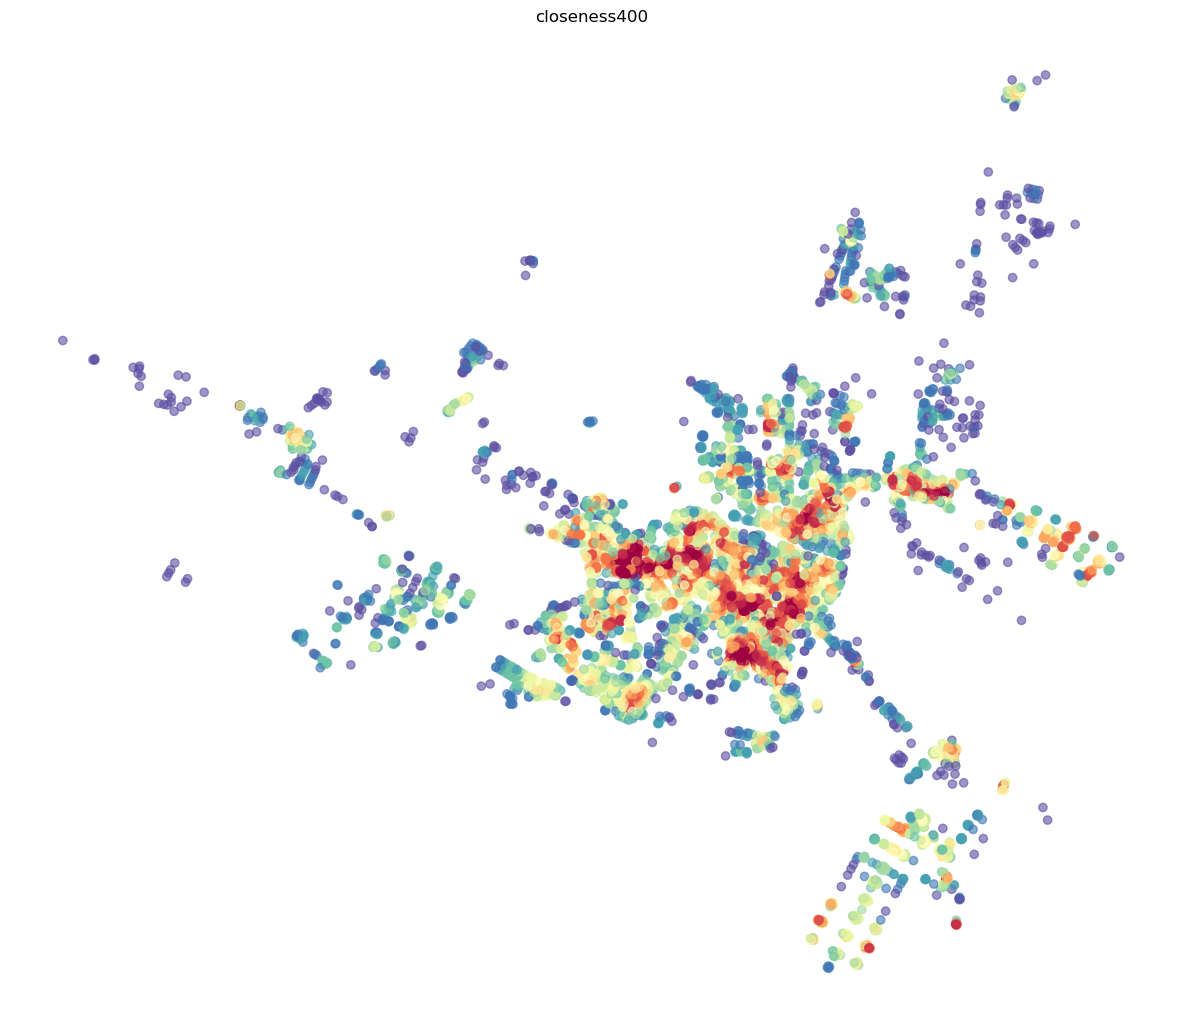

In [19]:
nodes = mm.nx_to_gdf(local_clos, lines=False)
ax = nodes.plot(
    column="closeness400",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("closeness400")

In [20]:
mm.mean_nodes(local_clos, "closeness400")

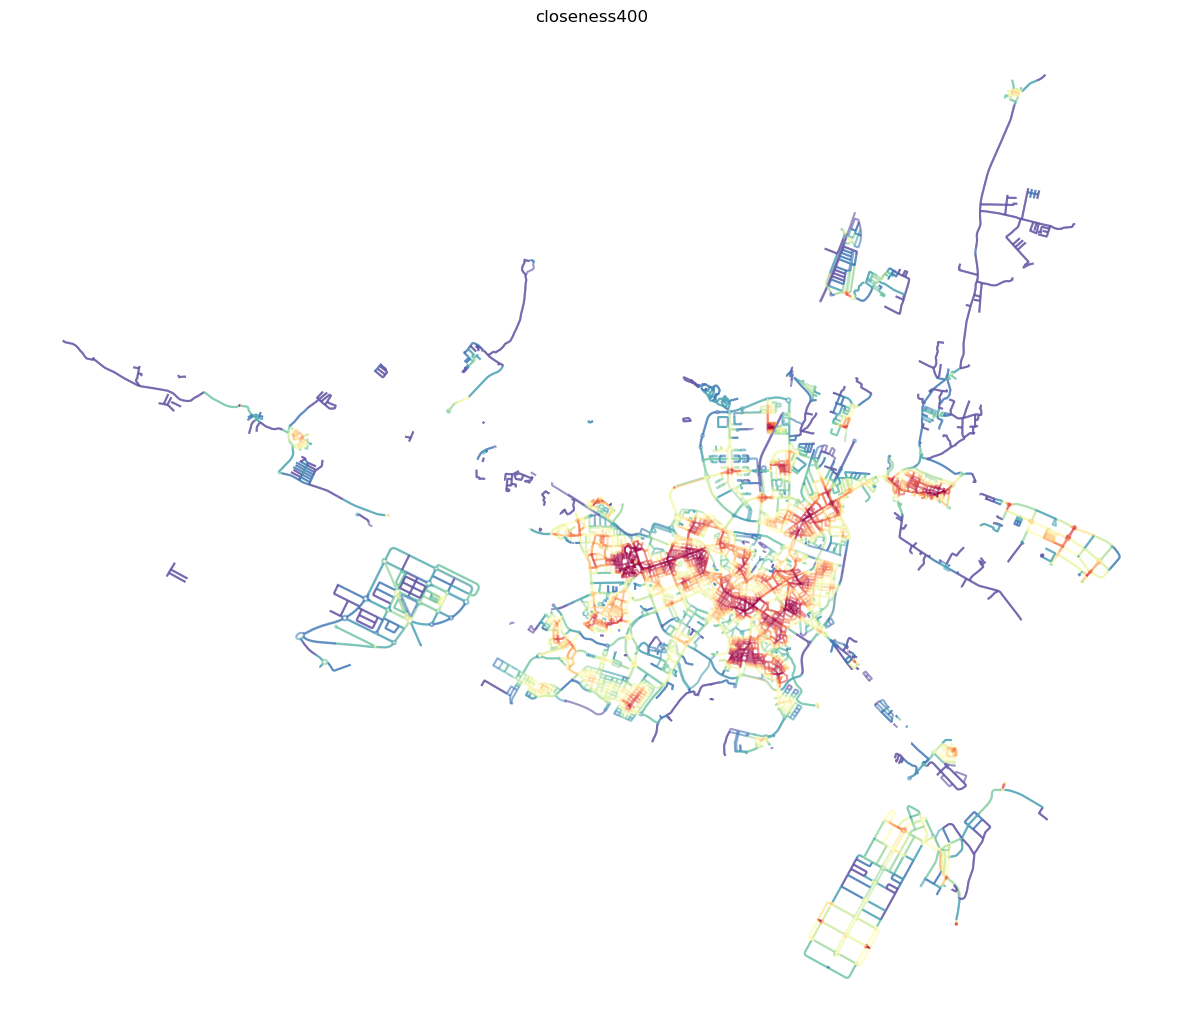

In [21]:
primal_gdf_clos400 = mm.nx_to_gdf(local_clos, points=False)

ax = primal_gdf_clos400.plot(
    column="closeness400",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("closeness400")

## Straightness

In [22]:
straighteness = mm.straightness_centrality(
    primal
)

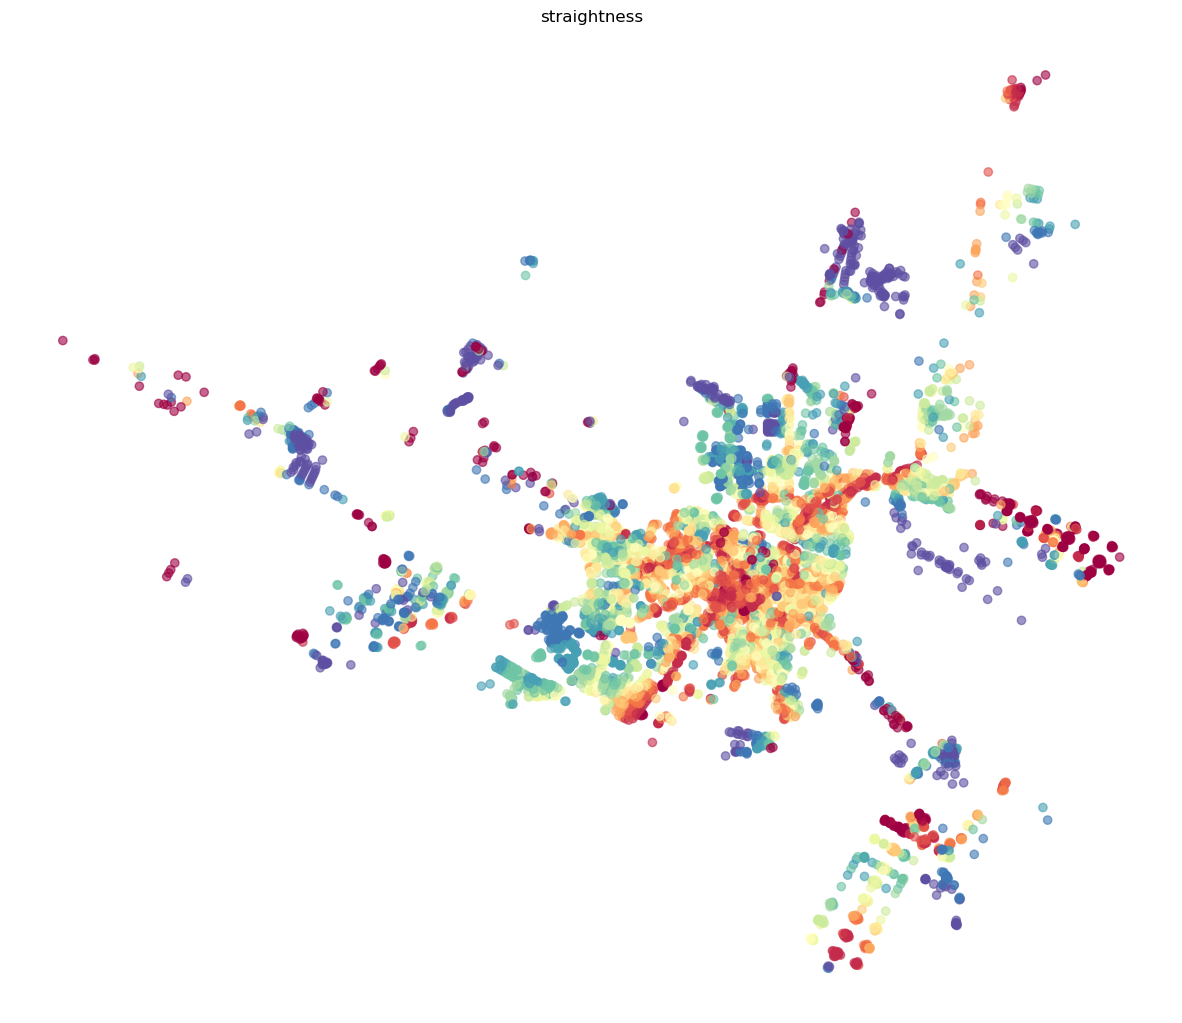

In [23]:
nodes = mm.nx_to_gdf(straighteness, lines=False)
ax = nodes.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("straightness")

In [24]:
mm.mean_nodes(straighteness, "straightness")

In [25]:
primal_gdf_str = mm.nx_to_gdf(straighteness, points=False)
primal_gdf_str.head()

,segment_id,highway,name,length,db_day,db_evening,db_night,noise_day,noise_evening,noise_night,geometry,width,openness,width_deviation,mm_len,straightness
0,30389382_249502424_0,residential,Calle Bruno Solano,61.613974,65.0,65.0,55.0,3,3,2,"LINESTRING (675261.037 4611935.746, 675263.416...",14.944760,0.375000,0.875412,61.701200,0.828224
1,30389382_30389461_0,primary,Paseo de Fernando el Católico,83.332676,75.0,70.0,60.0,4,4,3,"LINESTRING (675261.037 4611935.746, 675265.706...",32.776400,0.625000,4.648335,83.339083,0.830235
2,30389471_30389382_0,primary,Paseo de Fernando el Católico,148.754075,75.0,70.0,60.0,4,4,3,"LINESTRING (675177.171 4611812.87, 675183.439 ...",30.712891,0.578947,0.606859,148.768331,0.835820
3,249502424_249502441_0,residential,Calle Bruno Solano,62.446394,65.0,65.0,55.0,3,3,2,"LINESTRING (675313.172 4611902.746, 675365.929...",15.167460,0.250000,0.664342,62.534283,0.823010
4,249502424_266326619_0,residential,"['Calle de Félix Latassa', 'Calle de Don André...",128.472933,65.0,65.0,55.0,3,3,2,"LINESTRING (675313.172 4611902.746, 675352.306...",11.956801,0.416667,0.916044,128.478022,0.824770


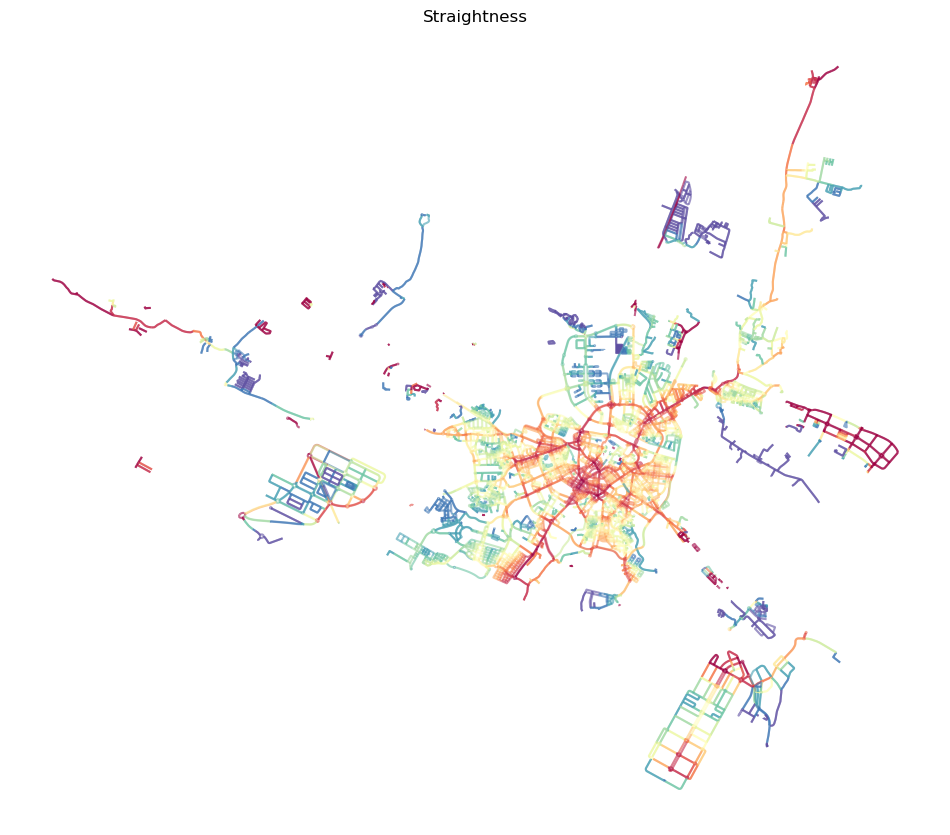

In [26]:
ax = primal_gdf_str.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
)
ax.set_axis_off()
_ = ax.set_title("Straightness")

## Create data frame

In [27]:
dataset = edges[['segment_id', 'width', 'openness']].copy()

dataset = (
    dataset
    .merge(primal_gdf_betw[['segment_id', 'betweenness_metric_e']], on='segment_id', how='left')
    .merge(primal_gdf_clos[['segment_id', 'closeness_global']], on='segment_id', how='left')
    .merge(primal_gdf_clos400[['segment_id', 'closeness400']], on='segment_id', how='left')
    .merge(primal_gdf_str[['segment_id', 'straightness']], on='segment_id', how='left')
    .rename(columns={
        'segment_id': 'road_id',
        'betweenness_metric_e': 'betweenness',
        'closeness400': 'closeness_400'
    })
    .fillna(0)
)

dataset.head()

,road_id,width,openness,betweenness,closeness_global,closeness_400,straightness
0,30389382_249502424_0,14.944760,0.375000,0.000679,0.000191,0.000022,0.828224
1,30389382_30389461_0,32.776400,0.625000,0.014229,0.000192,0.000023,0.830235
2,30389389_4398109455_0,37.421218,0.500000,0.001715,0.000183,0.000011,0.813448
3,30389391_30575132_0,50.000000,1.000000,0.027712,0.000187,0.000016,0.839237
4,30389400_3847861549_0,40.184419,0.666667,0.011389,0.000193,0.000020,0.838237


## Export dataset to CSV

In [28]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "momepy_roads_features.csv"), index=False)
print("Exported momepy_roads_features.csv")

Exported momepy_roads_features.csv
